# Семинар 5: Валидация больших языковых моделей

## Введение

В этом семинаре мы на практике разберем полный арсенал метрик и инструментов для оценки качества генерации LLM. Мы пройдем от простейших n-gram метрик (BLEU, ROUGE, chrF), напишем их с нуля, до обученных нейросетевых оценок (BERTScore), затем разберем подходы к проверке фактичности (NLI, QAGS) и закончим LLM-as-a-Judge и готовыми фреймворками.

> Не существует одной правильной метрики - нужно понимать, что каждая из них измеряет, где работает, а где ломается, и как их комбинировать.

**План семинара:**

1. Подготовка: загружаем QA-бенчмарк и генерируем ответы моделью с разными температурами
2. Классические метрики: BLEU / ROUGE / chrF - реализация с нуля и сравнение с библиотеками
3. Семантические и обученные метрики: BERTScore, Sentence-BERT cosine
4. Фактичность: NLI/entailment и QA-based (QAGS)
5. LLM-as-a-Judge: протоколы, промпты, смещения
6. Готовые фреймворки "под ключ"
7. Выводы и рекомендации

## Часть 1. Подготовка: бенчмарк, модель, генерация

### О датасете

Мы будем работать с **SQuAD** ([Stanford Question Answering Dataset](https://rajpurkar.github.io/SQuAD-explorer/)) - одним из самых известных бенчмарков для extractive QA. В SQuAD есть вопрос, контекст (параграф) и эталонный ответ - это идеальная структура для проверки метрик:

- **Есть reference** (эталонный ответ) -> можно считать reference-based метрики (BLEU, ROUGE, BERTScore)
- **Есть контекст** -> можно проверять groundedness/faithfulness (NLI, QAGS)
- **Есть вопрос** -> можно использовать LLM-as-judge и QA-based метрики


### Установка и импорты

In [2]:
!pip install -q \
  datasets>=2.20.0 \
  transformers>=4.45.0 \
  accelerate>=0.33.0 \
  evaluate>=0.4.3 \
  rouge-score>=0.1.2 \
  nltk>=3.8.1 \
  sacrebleu>=2.4.0 \
  bert-score>=0.3.13 \
  sentence-transformers>=3.0.0 \
  scikit-learn>=1.4.0 \
  tqdm>=4.66.0 \
  matplotlib>=3.8.0

In [3]:
import os
import sys
import json
import math
import random
import re
import warnings
from collections import Counter
from textwrap import shorten
from typing import List, Dict, Optional

import numpy as np
import pandas as pd

import torch
import torch.nn.functional as F

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSequenceClassification,
    pipeline,
)

warnings.filterwarnings("ignore")

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

from transformers.utils import logging as tf_logging
tf_logging.set_verbosity_error()

try:
    from huggingface_hub.utils import disable_progress_bars
    disable_progress_bars()
except Exception:
    pass

print(f"PyTorch: {torch.__version__}, CUDA: {torch.cuda.is_available()}")
print(f"Python: {sys.version.split()[0]}")

PyTorch: 2.10.0+cu128, CUDA: True
Python: 3.12.12


### Загружаем SQuAD v2

Берем validation split - он содержит ~11 тысяч примеров. Для семинара отберем 100 примеров с ответами (answerable).

In [5]:
# загружаем SQuAD v2
squad = load_dataset("rajpurkar/squad_v2", split="validation")
print(f"Всего примеров в validation: {len(squad)}")

# берем только примеры с ответами (answerable)
squad_answerable = squad.filter(lambda x: len(x["answers"]["text"]) > 0)
print(f"Answerable: {len(squad_answerable)}")

Generating train split:   0%|          | 0/130319 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/11873 [00:00<?, ? examples/s]

Всего примеров в validation: 11873


Filter:   0%|          | 0/11873 [00:00<?, ? examples/s]

Answerable: 5928


In [6]:
# подвыборка 100 примеров
indices = random.sample(range(len(squad_answerable)), 100)
samples = squad_answerable.select(indices)

# зацениваем
print("\nПример:")
print(f"Вопрос: {samples[0]['question']}")
print(f"Контекст: {samples[0]['context'][:200]}...")
print(f"Ответ(ы): {samples[0]['answers']['text']}")


Пример:
Вопрос: Where did France focus its efforts to rebuild its empire?
Контекст: France took control of Algeria in 1830 but began in earnest to rebuild its worldwide empire after 1850, concentrating chiefly in North and West Africa, as well as South-East Asia, with other conquests...
Ответ(ы): ['Africa', 'North and West Africa', 'North and West Africa', 'North and West Africa, as well as South-East Asia, with other conquests in Central and East Africa, as well as the South Pacific', 'North and West Africa, as well as South-East Asia,']


### Генерация ответов моделью

Мы используем небольшую модель - [Qwen/Qwen2.5-1.5B-Instruct](https://huggingface.co/Qwen/Qwen2.5-1.5B-Instruct), чтобы генерировать ответы на вопросы из SQuAD. Генерируем с **тремя температурами** (0.1, 0.7, 1.5), чтобы потом сравнить, как метрики реагируют на более свободную генерацию.

> Мы специально берем маленькую модель - она будет делать ошибки (ну мы надеемся 🤞), и это позволит нам увидеть, как метрики различают хорошие и плохие ответы.

In [7]:
model_name = "Qwen/Qwen2.5-1.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto" if torch.cuda.is_available() else None,
)

model.eval()
device = next(model.parameters()).device
print(f"Модель загружена на {device}")

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Модель загружена на cuda:0


In [8]:
def generate_answer(question: str, context: str, temperature: float = 0.7,
                    max_new_tokens: int = 100, seed: int = 42) -> str:
    """
    Генерирует ответ на вопрос по контексту.
    Используем chat-формат для instruct-модели.
    """
    torch.manual_seed(seed)

    messages = [
        {"role": "system", "content": "Answer the question. Be concise and precise."},
        {"role": "user", "content": f"Question: {question}\n\nAnswer:"}
    ]

    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=2048).to(device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            do_sample=temperature > 0,
            top_p=0.95 if temperature > 0 else None,
            pad_token_id=tokenizer.eos_token_id,
        )

    generated = outputs[0][inputs["input_ids"].shape[1]:]
    answer = tokenizer.decode(generated, skip_special_tokens=True).strip()
    return answer

# Тест
test_answer = generate_answer(samples[0]["question"], samples[0]["context"], temperature=0.7)
print(f"Вопрос: {samples[0]['question']}")
print(f"Эталон: {samples[0]['answers']['text'][0]}")
print(f"Модель: {test_answer}")

Вопрос: Where did France focus its efforts to rebuild its empire?
Эталон: Africa
Модель: France focused its efforts to rebuild its empire in Africa during the late 19th and early 20th centuries through colonization and expansion.


### Генерация ответов с тремя температурами

Температура контролирует случайность генерации:
- **T=0.1** - почти greedy, модель выбирает самые вероятные токены
- **T=0.7** - умеренный sampling, баланс между точностью и разнообразием
- **T=1.5** - высокая случайность, модель может галлюцинировать (во всяком случае, мы на это расчитываем)

Формально температура масштабирует логиты (сырые оценки модели) перед softmax:

$$p_i = \frac{\exp(z_i / T)}{\sum_j \exp(z_j / T)}$$

Здесь $z_i$ - логит (оценка) для $i$-го слова, $T$ - температура, $p_i$ - итоговая вероятность. При $T \to 0$ все сдвигается к одному самому вероятному слову, при $T \to \infty$ - к равномерному случайному выбору.

> Мы генерируем ответы с тремя температурами, чтобы увидеть: как метрики реагируют на разный уровень свободы генерации

In [9]:
temperatures = [0.1, 0.7, 1.5]
results = {t: [] for t in temperatures}
references = []
questions = []
contexts = []

for i in tqdm(range(len(samples)), desc="Генерация ответов"):
    q = samples[i]["question"]
    ctx = samples[i]["context"]
    ref = samples[i]["answers"]["text"][0] # берем первый эталонный ответ

    questions.append(q)
    contexts.append(ctx)
    references.append(ref)

    for t in temperatures:
        ans = generate_answer(q, ctx, temperature=t, seed=42)
        results[t].append(ans)

print(f"Сгенерировано: {len(references)} x {len(temperatures)} = {len(references) * len(temperatures)} ответов")

Генерация ответов:   0%|          | 0/100 [00:00<?, ?it/s]

Сгенерировано: 100 x 3 = 300 ответов


In [10]:
for i in range(3):
    print(f"\n{'='*80}")
    print(f"Вопрос: {questions[i]}")
    print(f"Эталон: {references[i]}")
    for t in temperatures:
        print(f"  T={t}: {results[t][i]}")


Вопрос: Where did France focus its efforts to rebuild its empire?
Эталон: Africa
  T=0.1: France focused its efforts on rebuilding its empire in Africa, particularly in French West Africa (now Senegal, Guinea, Mali, Ivory Coast, Burkina Faso, Benin) and French Equatorial Africa (now Cameroon, Chad, Central African Republic, Congo, Gabon).
  T=0.7: France focused its efforts to rebuild its empire in Africa during the late 19th and early 20th centuries through colonization and expansion.
  T=1.5: France focused its efforts towards decolonizing some African countries by granting them independence or support for a peaceful breakaway in regions where nationalism was gaining traction, especially following World War II and the post-Cold War era.

Вопрос: What protestant religions made Northern European counties safe for Huguenot immigration?
Эталон: Lutheran and Reformed
  T=0.1: Protestantism, particularly Calvinism, made Northern European counties safe for Huguenot immigration by providing

## Часть 2. Классические метрики: BLEU / ROUGE / chrF

Эти метрики основаны на **поверхностном совпадении** между reference (эталон) и hypothesis (ответ модели). Они быстры, интерпретируемы и хорошо работают для коротких фактоидных ответов, но плохо улавливают парафразы и смысловое сходство.

### 2.1 BLEU - Bilingual Evaluation Understudy

Интуиция: BLEU отвечает на вопрос: Какая доля слов (и фраз) из ответа модели встречается в эталоне?

Представьте, что вы сравниваете два текста, выделяя маркером совпадающие слова. BLEU - это примерно доля выделенного.

**Вспомним про n-граммы**

n-грамма - это последовательность из $n$ подряд идущих слов:
- 1-граммы (униграммы): отдельные слова -> ["the", "cat", "sat"]
- 2-граммы (биграммы): пары слов -> ["the cat", "cat sat"]
- 3-граммы (триграммы): тройки слов -> ["the cat sat"]

Чем длиннее n-грамма, тем строже проверка: совпадение 4-граммы означает, что четыре слова подряд совпали - это уже почти целая фраза.

**Формула: модифицированная n-gram precision**

Precision (точность) - из того, что сказала модель, сколько правда есть в эталоне?

$$p_n = \frac{\sum_{\text{n-gram} \in \hat{y}} \min\bigl(\text{Count}(\text{n-gram}, \hat{y}),\; \text{Count}(\text{n-gram}, y)\bigr)}{\sum_{\text{n-gram} \in \hat{y}} \text{Count}(\text{n-gram}, \hat{y})}$$

Здесь:
- $\hat{y}$ - ответ модели (hypothesis, гипотеза)
- $y$ - эталонный ответ (reference)
- $\text{Count}(\text{n-gram}, \hat{y})$ - сколько раз эта n-грамма встречается в ответе модели

> Зачем `min` (clipping)? Без него модель могла бы повторить одно слово 100 раз и получить 100% precision. Clipping ограничивает: "the" встречается в эталоне 2 раза, значит больше 2 совпадений не засчитаем.

**Brevity Penalty** (штраф за краткость)

Precision не штрафует слишком короткие ответы: если модель скажет одно верное слово, precision = 100%. Поэтому добавляется Brevity Penalty:

$$\text{BP} = \begin{cases} 1 & \text{если } |\hat{y}| \geq |y| \\ \exp\bigl(1 - |y|/|\hat{y}|\bigr) & \text{иначе} \end{cases}$$

Если ответ модели короче эталона - штрафуем. Если длиннее или равен - не штрафуем (BP = 1).

**Итоговый BLEU**

$$\text{BLEU-N} = \text{BP} \cdot \exp\left(\sum_{n=1}^{N} w_n \log p_n\right)$$

Это **геометрическое среднее** precision по n-граммам от 1 до N, умноженное на BP. Веса обычно равные: $w_n = 1/N$. Стандарт - BLEU-4 (n-граммы до 4).

**Ограничения BLEU:**
- Не понимает синонимы: кот и кошка - разные слова, совпадений нет
- Не понимает парафразы: Он сел на стул и Мужчина расположился на сиденье - BLEU ≈ 0
- Ориентирован на precision -> не штрафует за пропущенную информацию

#### Реализация BLEU с нуля

In [11]:
def _tokenize_ws(text: str) -> List[str]:
    # lower + split
    return text.lower().split()

def get_ngrams(tokens: List[str], n: int) -> Counter:
    return Counter(tuple(tokens[i:i+n]) for i in range(len(tokens) - n + 1))

def _closest_ref_length(ref_lens: List[int], hyp_len: int) -> int:
    # берем reference length, ближайшую к длине hypothesis
    # при равенстве - выбираем более короткую
    closest = min(ref_lens, key=lambda rl: (abs(rl - hyp_len), rl))
    return closest

def bleu_score(
    reference: str | List[str],
    hypothesis: str,
    max_n: int = 4,
    weights: Optional[List[float]] = None,
    smooth_method: str = "exp", # 'none' | 'floor' | 'add-k' | 'exp'
    smooth_value: Optional[float] = None,
    effective_order: bool = True,
) -> Dict:
    """
    Sentence-level BLEU (0..1) для пары (reference(s), hypothesis).

    У нас есть:
    - multiple references
    - effective_order=True: для коротких ответов не обнуляем за отсутствующие 4-граммы
    - smoothing: none/floor/add-k/exp (в духе sacrebleu)
    """

    if isinstance(reference, str):
        references = [reference]
    else:
        references = list(reference)

    if weights is None:
        weights = [1.0 / max_n] * max_n
    assert len(weights) == max_n

    hyp_tokens = _tokenize_ws(hypothesis)
    ref_tokens_list = [_tokenize_ws(r) for r in references]

    hyp_len = len(hyp_tokens)
    if hyp_len == 0:
        return {"bleu": 0.0, "precisions": [0.0]*max_n, "bp": 0.0, "ref_len": 0, "hyp_len": 0}

    ref_lens = [len(rt) for rt in ref_tokens_list]
    ref_len = _closest_ref_length(ref_lens, hyp_len)

    # Brevity penalty
    if hyp_len > ref_len:
        bp = 1.0
    else:
        bp = math.exp(1.0 - float(ref_len) / float(hyp_len))

    # modified precisions per n
    correct = [0] * max_n
    total = [0] * max_n

    for n in range(1, max_n + 1):
        hyp_ngrams = get_ngrams(hyp_tokens, n)
        total[n-1] = sum(hyp_ngrams.values())

        # для multiple refs берем максимальные частоты n-gram по refs
        max_ref_counts = Counter()
        for ref_tokens in ref_tokens_list:
            ref_ngrams = get_ngrams(ref_tokens, n)
            for ng, cnt in ref_ngrams.items():
                if cnt > max_ref_counts.get(ng, 0):
                    max_ref_counts[ng] = cnt

        clipped = 0
        for ng, cnt in hyp_ngrams.items():
            clipped += min(cnt, max_ref_counts.get(ng, 0))
        correct[n-1] = clipped

    # если нет совпадений даже для 1-грамм - BLEU=0
    if not any(correct):
        return {"bleu": 0.0, "precisions": [0.0]*max_n, "bp": bp, "ref_len": ref_len, "hyp_len": hyp_len}

    # defaults (как у sacrebleu - чтоб мы потом могли сравнить)
    if smooth_value is None:
        smooth_value = 0.1 if smooth_method == "floor" else 1.0

    precisions = [0.0] * max_n
    smooth_mteval = 1.0
    eff_order = max_n

    for n in range(1, max_n + 1):
        if total[n-1] == 0:
            precisions[n-1] = 0.0
            if effective_order:
                eff_order = n - 1
            continue

        if correct[n-1] == 0:
            if smooth_method == "exp":
                smooth_mteval *= 2.0
                precisions[n-1] = 1.0 / (smooth_mteval * total[n-1])
            elif smooth_method == "floor":
                precisions[n-1] = float(smooth_value) / float(total[n-1])
            elif smooth_method == "add-k":
                if n > 1:
                    precisions[n-1] = (correct[n-1] + smooth_value) / (total[n-1] + smooth_value)
                else:
                    precisions[n-1] = 0.0
            else:  # 'none'
                precisions[n-1] = 0.0
        else:
            if smooth_method == "add-k" and n > 1:
                precisions[n-1] = (correct[n-1] + smooth_value) / (total[n-1] + smooth_value)
            else:
                precisions[n-1] = correct[n-1] / total[n-1]

        if effective_order and precisions[n-1] > 0:
            eff_order = n

    if effective_order:
        eff_order = max(1, eff_order)
        weights_eff = [1.0/eff_order]*eff_order

        # усечём precisions до eff_order
        used_prec = precisions[:eff_order]
    else:
        weights_eff = weights
        used_prec = precisions

    # geo mean
    # если где-то p_n = 0 и smoothing='none', BLEU станет 0 (через log)
    sum_logs = 0.0
    for w, p in zip(weights_eff, used_prec):
        if p <= 0:
            return {"bleu": 0.0, "precisions": precisions, "bp": bp, "ref_len": ref_len, "hyp_len": hyp_len}
        sum_logs += w * math.log(p)

    bleu = bp * math.exp(sum_logs)
    return {"bleu": bleu, "precisions": precisions, "bp": bp, "ref_len": ref_len, "hyp_len": hyp_len}


# тесты BLEU
ref = "The cat is on the mat"
hyp = "The the the the the the"
r = bleu_score(ref, hyp, smooth_method="exp", effective_order=True)
print(f"Reference: '{ref}'")
print(f"Hypothesis: '{hyp}'")
print(f"BLEU (0..1): {r['bleu']:.6f} | BLEU×100: {r['bleu']*100:.2f}")
print(f"Precisions: {[f'{p:.3f}' for p in r['precisions']]}")
print(f"BP: {r['bp']:.4f}")

Reference: 'The cat is on the mat'
Hypothesis: 'The the the the the the'
BLEU (0..1): 0.096524 | BLEU×100: 9.65
Precisions: ['0.333', '0.100', '0.062', '0.042']
BP: 1.0000


In [12]:
examples = [
    ("The cat sat on the mat", "The cat sat on the mat"),
    ("The cat sat on the mat", "The cat is on the mat"),
    ("The cat sat on the mat", "A feline rested on a rug"),
    ("The cat sat on the mat", "Dogs are running in the park"),
    ("The cat sat on the mat", "cat"),
]

print(f"\n{'Reference':<35} {'Hypothesis':<35} {'BLEU×100':>10} {'BP':>6}")
print("-"*95)
for ref, hyp in examples:
    rr = bleu_score(ref, hyp, smooth_method="exp", effective_order=True)
    print(f"{ref:<35} {hyp:<35} {rr['bleu']*100:>10.2f} {rr['bp']:>6.3f}")


Reference                           Hypothesis                            BLEU×100     BP
-----------------------------------------------------------------------------------------------
The cat sat on the mat              The cat sat on the mat                  100.00  1.000
The cat sat on the mat              The cat is on the mat                    37.99  1.000
The cat sat on the mat              A feline rested on a rug                  8.12  1.000
The cat sat on the mat              Dogs are running in the park              8.12  1.000
The cat sat on the mat              cat                                       0.00  0.007


**Наблюдения:**
- Идеальное совпадение -> BLEU = 1.0
- Замена одного слова -> BLEU тоже нулевой, ведь 4-граммы ломаются
- Парафраз -> BLEU ≈ 0 (нет пересечения n-грамм!)
- Это главная слабость BLEU: он не понимает синонимы и парафразы


#### Сравнение с библиотечной реализацией (sacrebleu)

`sacrebleu` - стандартная библиотека для вычисления BLEU. Она реализует **corpus-level BLEU** (не sentence-level!), с правильной токенизацией и smoothing.

In [13]:
import sacrebleu

# sacrebleu работает на corpus level - передаём списки
ref_list = ["The cat sat on the mat"]
hyp_list = ["The cat is on the mat"]

# sacrebleu ожидает список списков references (для multiple references)
bleu_sacre = sacrebleu.corpus_bleu(hyp_list, [ref_list])
print(f"sacrebleu BLEU: {bleu_sacre.score:.2f}")
print(f"Precisions: {bleu_sacre.precisions}")
print(f"BP: {bleu_sacre.bp:.4f}")
print(f"\nВся информация:\n{bleu_sacre}")

sacrebleu BLEU: 37.99
Precisions: [83.33333333333333, 60.0, 25.0, 16.666666666666668]
BP: 1.0000

Вся информация:
BLEU = 37.99 83.3/60.0/25.0/16.7 (BP = 1.000 ratio = 1.000 hyp_len = 6 ref_len = 6)


**Гиперпараметры sacrebleu:**

- `smooth_method`: метод сглаживания нулевых precision (по умолчанию 'exp' для sentence-level, 'none' для corpus-level). Варианты: 'none', 'floor', 'add-k', 'exp'
- `smooth_value`: параметр сглаживания (epsilon для floor, k для add-k)
- `max_ngram_order`: максимальный порядок n-грамм (по умолчанию 4)
- `effective_order`: если True, при sentence-level используются только n-граммы до длины предложения
- `tokenize`: метод токенизации ('none', '13a', 'intl', 'zh', 'ja-mecab')

Сглаживание критически важно для sentence-level BLEU: без него BLEU = 0 для любого предложения, где хотя бы одна n-gram precision = 0.

In [14]:
# сравнение методов сглаживания

ref = "The quick brown fox jumps over the lazy dog"
hyp = "The quick brown fox leaps over a lazy dog"

for method in ['none', 'floor', 'add-k', 'exp']:
    try:
        score = sacrebleu.sentence_bleu(hyp, [ref], smooth_method=method)
        print(f"smooth={method:<8} BLEU={score.score:>6.2f}  precisions={score.precisions}")
    except Exception as e:
        print(f"smooth={method:<8} Error: {e}")

smooth=none     BLEU= 36.89  precisions=[77.77777777777777, 50.0, 28.571428571428573, 16.666666666666668]
smooth=floor    BLEU= 36.89  precisions=[77.77777777777777, 50.0, 28.571428571428573, 16.666666666666668]
smooth=add-k    BLEU= 46.39  precisions=[77.77777777777777, 55.55555555555556, 37.5, 28.571428571428573]
smooth=exp      BLEU= 36.89  precisions=[77.77777777777777, 50.0, 28.571428571428573, 16.666666666666668]


### 2.2 ROUGE - Recall-Oriented Understudy for Gisting Evaluation

**ROUGE** (Lin, 2004) создан для оценки суммаризации. В отличие от BLEU, ориентирован на recall - какая доля n-грамм из reference покрыта в hypothesis.

**Интуиция:** Если BLEU спрашивает из ответа модели, что совпало с эталоном? (precision), то ROUGE спрашивает наоборот: из эталона, что покрыто ответом модели? (recall).

Пример:
- Эталон: "кот сидел на коврике"
- Модель: "кот сидел на коврике и мурлыкал"

BLEU-precision: модель сказала 6 слов, 5 из них в эталоне -> 5/6 ≈ 0.83
ROUGE-recall: эталон содержит 4 слова, все 4 покрыты моделью -> 4/4 = 1.0

То есть ROUGE больше заботится о полноте: не пропустили ли мы что-то из эталона?

**ROUGE-N: overlap по n-граммам (с фокусом на recall)**

$$\text{ROUGE-N}_{recall} = \frac{\text{совпавшие n-граммы}}{\text{все n-граммы в эталоне}}$$

На практике всегда считают precision, recall и F1 (гармоническое среднее) - и обычно отчитываются именно по F1.

**ROUGE-L: Longest Common Subsequence (LCS)**

LCS - самая длинная подпоследовательность, общая для двух текстов. Не путать с подстрокой! Подпоследовательность может быть с пропусками:

- Эталон: **the** quick **brown** fox **jumps**
- Модель: **the** lazy **brown** dog **jumps**
- LCS: the brown jumps (длина 3)

ROUGE-L удобен тем, что не привязан к фиксированной длине n-граммы - он ловит общую структуру предложения.

$$R_{lcs} = \frac{LCS(y, \hat{y})}{|y|}, \quad P_{lcs} = \frac{LCS(y, \hat{y})}{|\hat{y}|}, \quad F1 = \frac{2 \cdot P \cdot R}{P + R}$$

In [15]:
# реализация ROUGE с нуля

def rouge_n(reference: str, hypothesis: str, n: int = 1) -> Dict[str, float]:
    """
    Вычисляет ROUGE-N (precision, recall, F1).
    Recall-oriented: знаменатель - по n-граммам reference.
    """
    ref_tokens = reference.lower().split()
    hyp_tokens = hypothesis.lower().split()

    ref_ngrams = get_ngrams(ref_tokens, n) # переиспользуем функцию из BLEU
    hyp_ngrams = get_ngrams(hyp_tokens, n)

    # пересечение (с учетом частот)
    overlap = 0
    for ngram, count in ref_ngrams.items():
        overlap += min(count, hyp_ngrams.get(ngram, 0))

    ref_count = sum(ref_ngrams.values())
    hyp_count = sum(hyp_ngrams.values())

    recall = overlap / ref_count if ref_count > 0 else 0.0
    precision = overlap / hyp_count if hyp_count > 0 else 0.0

    if precision + recall > 0:
        f1 = 2 * precision * recall / (precision + recall)
    else:
        f1 = 0.0

    return {"precision": precision, "recall": recall, "f1": f1}


def lcs_length(x: List[str], y: List[str]) -> int:
    """Длина Longest Common Subsequence (динамическое программирование)."""
    m, n = len(x), len(y)
    # dp[i][j] = длина LCS для x[:i] и y[:j]
    dp = [[0] * (n + 1) for _ in range(m + 1)]

    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if x[i - 1] == y[j - 1]:
                dp[i][j] = dp[i - 1][j - 1] + 1
            else:
                dp[i][j] = max(dp[i - 1][j], dp[i][j - 1])

    return dp[m][n]


def rouge_l(reference: str, hypothesis: str, beta: float = 1.0) -> Dict[str, float]:
    """
    Вычисляет ROUGE-L на основе LCS.
    beta: параметр F-меры (beta=1 -> F1)
    """
    ref_tokens = reference.lower().split()
    hyp_tokens = hypothesis.lower().split()

    lcs = lcs_length(ref_tokens, hyp_tokens)

    recall = lcs / len(ref_tokens) if len(ref_tokens) > 0 else 0.0
    precision = lcs / len(hyp_tokens) if len(hyp_tokens) > 0 else 0.0

    if precision + recall > 0:
        f1 = (1 + beta**2) * precision * recall / (beta**2 * precision + recall)
    else:
        f1 = 0.0

    return {"precision": precision, "recall": recall, "f1": f1}

In [16]:
ref = "The cat sat on the mat"
hyp = "The cat is on the mat"

r1 = rouge_n(ref, hyp, n=1)
r2 = rouge_n(ref, hyp, n=2)
rl = rouge_l(ref, hyp)

print(f"ROUGE-1: P={r1['precision']:.3f} R={r1['recall']:.3f} F1={r1['f1']:.3f}")
print(f"ROUGE-2: P={r2['precision']:.3f} R={r2['recall']:.3f} F1={r2['f1']:.3f}")
print(f"ROUGE-L: P={rl['precision']:.3f} R={rl['recall']:.3f} F1={rl['f1']:.3f}")

ROUGE-1: P=0.833 R=0.833 F1=0.833
ROUGE-2: P=0.600 R=0.600 F1=0.600
ROUGE-L: P=0.833 R=0.833 F1=0.833


In [17]:
# сравнение с библиотечной реализацией
from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
scores = scorer.score(ref, hyp)

print("Библиотечная реализация (rouge-score, use_stemmer=True):")
for key, val in scores.items():
    print(f"  {key}: P={val.precision:.3f} R={val.recall:.3f} F1={val.fmeasure:.3f}")

print("\nНаша реализация (без стемминга):")
print(f"ROUGE-1: P={r1['precision']:.3f} R={r1['recall']:.3f} F1={r1['f1']:.3f}")
print(f"ROUGE-2: P={r2['precision']:.3f} R={r2['recall']:.3f} F1={r2['f1']:.3f}")
print(f"ROUGE-L: P={rl['precision']:.3f} R={rl['recall']:.3f} F1={rl['f1']:.3f}")
print("\n(Различия связаны со стеммингом — Porter stemmer объединяет формы слов)")

Библиотечная реализация (rouge-score, use_stemmer=True):
  rouge1: P=0.833 R=0.833 F1=0.833
  rouge2: P=0.600 R=0.600 F1=0.600
  rougeL: P=0.833 R=0.833 F1=0.833

Наша реализация (без стемминга):
ROUGE-1: P=0.833 R=0.833 F1=0.833
ROUGE-2: P=0.600 R=0.600 F1=0.600
ROUGE-L: P=0.833 R=0.833 F1=0.833

(Различия связаны со стеммингом — Porter stemmer объединяет формы слов)


**Гиперпараметры rouge-score:**

- `use_stemmer` (bool): применять ли Porter stemmer для нормализации (sat -> sat, sitting -> sit). Повышает recall, но может быть неточным для не-английских языков
- `split_summaries` (bool): разделять ли текст на предложения для ROUGE-L (sentence-level vs summary-level)
- Варианты ROUGE: `rouge1`, `rouge2`, `rougeL`, `rougeLsum` (summary-level LCS)

### 2.3 chrF - Character n-gram F-score

**Интуиция:** BLEU и ROUGE работают на уровне слов. Но что если слова почти совпадают, отличаясь на одну букву? Например, running vs runs - это разные слова для BLEU, но очень похожие последовательности символов.

chrF (Popović, 2015)  работает на уровне символов: разбивает текст на короткие кусочки букв (символьные n-граммы) и считает, сколько совпало.

**Пример символьных 3-грамм для слова cat:** "_ca", "cat", "at_" (где _ - пробел)

Даже если слова разные, их символьные n-граммы могут частично совпадать: cat и cats совпадают в "cat", "ca_", "_ca" - chrF это поймает, а BLEU - нет.

Это особенно полезно для:
- Морфологически богатых языков (русский, немецкий) - где одно слово имеет десятки форм
- Текстов с опечатками
- Составных слов (нем. "[Donaudampfschiffahrtsgesellschaft](https://en.wikipedia.org/wiki/Donaudampfschiffahrtsgesellschaft)")

**Формула**

Для каждого порядка $n$ (обычно от 1 до 6) считаем precision и recall по символьным n-граммам, затем усредняем и берём F-меру:

$$\text{chrF} = (1 + \beta^2) \cdot \frac{\text{avg_precision} \cdot \text{avg_recall}}{\beta^2 \cdot \text{avg_precision} + \text{avg_recall}}$$

$\beta = 2$ по умолчанию, то есть recall важнее precision вдвое (как в ROUGE).

> **chrF++** - расширение, которое добавляет к символьным n-граммам еще и словесные n-граммы (обычно 1- и 2-граммы слов). Это комбинация обоих подходов.


In [18]:
def char_ngrams(text: str, n: int) -> Counter:
    """Извлекает символьные n-граммы (без пробелов между словами)."""
    # убираем пробелы для чистых символьных n-грамм? Нет - стандарт chrF работает с пробелами
    # обычно считают по словам отдельно, потом конкатенируют символы внутри слова
    # упрощённый вариант: символьные n-граммы по всему тексту
    return Counter(tuple(text[i:i+n]) for i in range(len(text) - n + 1))


def chrf_score(reference: str, hypothesis: str, max_n: int = 6, beta: float = 2.0) -> Dict:
    """
    Вычисляет chrF (character n-gram F-score).

    Параметры:
        max_n: максимальный порядок символьных n-грамм (стандарт — 6)
        beta: параметр F-меры (стандарт — 2, т.е. recall важнее precision в 2 раза)
    """
    ref = reference.lower()
    hyp = hypothesis.lower()

    precisions = []
    recalls = []

    for n in range(1, max_n + 1):
        ref_ngrams = char_ngrams(ref, n)
        hyp_ngrams = char_ngrams(hyp, n)

        overlap = 0
        for ng, cnt in hyp_ngrams.items():
            overlap += min(cnt, ref_ngrams.get(ng, 0))

        p = overlap / sum(hyp_ngrams.values()) if sum(hyp_ngrams.values()) > 0 else 0.0
        r = overlap / sum(ref_ngrams.values()) if sum(ref_ngrams.values()) > 0 else 0.0
        precisions.append(p)
        recalls.append(r)

    avg_p = np.mean(precisions) if precisions else 0.0
    avg_r = np.mean(recalls) if recalls else 0.0

    if avg_p + avg_r > 0:
        f = (1 + beta**2) * avg_p * avg_r / (beta**2 * avg_p + avg_r)
    else:
        f = 0.0

    return {"chrf": f, "precision": avg_p, "recall": avg_r}

In [19]:
ref = "The cat sat on the mat"
hyp = "The cat is on the mat"
r = chrf_score(ref, hyp)
print(f"chrF: {r['chrf']:.4f} (P={r['precision']:.3f}, R={r['recall']:.3f})")

chrF: 0.7229 (P=0.754, R=0.716)


In [20]:
# теперь парафраз - chrF должен быть чуть лучше BLEU тут
hyp2 = "A feline rested on a rug"
r2 = chrf_score(ref, hyp2)
b2 = bleu_score(ref, hyp2)
print(f"Парафраз:")
print(f"chrF: {r2['chrf']:.4f}")
print(f"BLEU: {b2['bleu']:.4f}")
print("chrF чуть лучше, т.к. символьные n-граммы улавливают частичные совпадения (the/the, at/at)")

Парафраз:
chrF: 0.1528
BLEU: 0.0812
chrF чуть лучше, т.к. символьные n-граммы улавливают частичные совпадения (the/the, at/at)


In [21]:
# sacrebleu chrF

ref_text = "The cat sat on the mat"
hyp_text = "The cat is on the mat"

chrf_sacre = sacrebleu.corpus_chrf([hyp_text], [[ref_text]])
print(f"sacrebleu chrF: {chrf_sacre.score:.2f}")
print(f"Наш chrF: {chrf_score(ref_text, hyp_text)['chrf']*100:.2f}")

# chrF++ (с word n-grams)
chrf_pp = sacrebleu.corpus_chrf([hyp_text], [[ref_text]], word_order=2)
print(f"sacrebleu chrF++: {chrf_pp.score:.2f}")

sacrebleu chrF: 61.93
Наш chrF: 72.29
sacrebleu chrF++: 64.37


**Гиперпараметры sacrebleu chrF:**

- `char_order` (int): максимальный порядок символьных n-грамм (по умолчанию 6)
- `word_order` (int): порядок словесных n-грамм (0 = chrF, 2 = chrF++)
- `beta` (float): параметр F-меры (по умолчанию 2)
- `eps_smoothing` (bool): epsilon-сглаживание

### 2.4 Сравнение метрик на сгенерированных ответах

Теперь применим все три метрики к нашим сгенерированным ответам с разными температурами. Ожидаем: чем выше температура, тем ниже overlap-метрики (ответы становятся более случайными и далёкими от эталона).

In [22]:
def _s(x, w=160):
    return shorten(str(x).replace("\n", " "), width=w, placeholder="…")

scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

metric_results = {t: {"bleu": [], "rouge1": [], "rouge2": [], "rougeL": [], "chrf": []}
                  for t in temperatures}

PRINT_N = 3
SHOW_CONTEXT = False # если хочется печатать кусок контекста

for i in range(len(references)):
    ref = references[i]

    if i < PRINT_N:
        print("\n" + "="*90)
        print(f"idx={i}")
        print(f"Q:   {_s(questions[i], 220)}")
        if SHOW_CONTEXT:
            print(f"C:   {_s(contexts[i], 260)}")
        print(f"REF: {_s(ref, 220)}")

    for t in temperatures:
        hyp = results[t][i]

        # BLEU (sentence-level, smoothed)
        b = sacrebleu.sentence_bleu(hyp, [ref], smooth_method='exp')
        metric_results[t]["bleu"].append(b.score)

        # ROUGE
        r = scorer.score(ref, hyp)
        metric_results[t]["rouge1"].append(r['rouge1'].fmeasure * 100)
        metric_results[t]["rouge2"].append(r['rouge2'].fmeasure * 100)
        metric_results[t]["rougeL"].append(r['rougeL'].fmeasure * 100)

        # chrF
        c = sacrebleu.sentence_chrf(hyp, [ref])
        metric_results[t]["chrf"].append(c.score)

        # печать гипотезы + метрик для примера
        if i < PRINT_N:
            print(f"\nT={t}")
            print(f"HYP: {_s(hyp, 220)}")
            print(f"BLEU: {b.score:6.2f} | chrF: {c.score:6.2f} | "
                  f"R1: {r['rouge1'].fmeasure*100:6.2f} | "
                  f"R2: {r['rouge2'].fmeasure*100:6.2f} | "
                  f"RL: {r['rougeL'].fmeasure*100:6.2f}")

print("\n" + "-" * 72)
print(f"{'Metric':<12}", end="")
for t in temperatures:
    print(f"{('T=' + str(t)):>12}", end="")
print()
print("-" * 72)

for metric_name in ["bleu", "rouge1", "rouge2", "rougeL", "chrf"]:
    print(f"{metric_name:<12}", end="")
    for t in temperatures:
        vals = metric_results[t][metric_name]
        print(f"{np.mean(vals):>12.2f}", end="")
    print()


idx=0
Q:   Where did France focus its efforts to rebuild its empire?
REF: Africa

T=0.1
HYP: France focused its efforts on rebuilding its empire in Africa, particularly in French West Africa (now Senegal, Guinea, Mali, Ivory Coast, Burkina Faso, Benin) and French Equatorial Africa (now Cameroon, Chad, Central…
BLEU:   0.71 | chrF:   7.70 | R1:   5.41 | R2:   0.00 | RL:   5.41

T=0.7
HYP: France focused its efforts to rebuild its empire in Africa during the late 19th and early 20th centuries through colonization and expansion.
BLEU:   1.65 | chrF:  13.33 | R1:   8.70 | R2:   0.00 | RL:   8.70

T=1.5
HYP: France focused its efforts towards decolonizing some African countries by granting them independence or support for a peaceful breakaway in regions where nationalism was gaining traction, especially following World War…
BLEU:   0.00 | chrF:   7.77 | R1:   0.00 | R2:   0.00 | RL:   0.00

idx=1
Q:   What protestant religions made Northern European counties safe for Huguenot immigration?


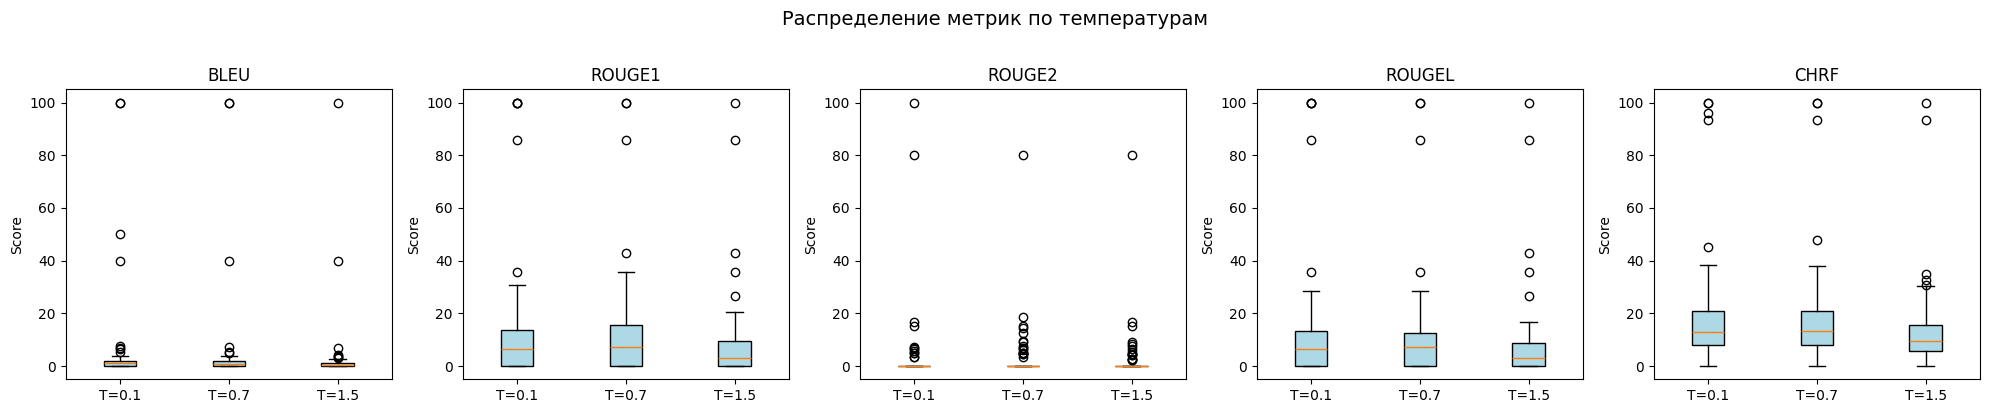

In [23]:
# распределения
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
metric_names = ["bleu", "rouge1", "rouge2", "rougeL", "chrf"]

for ax, metric_name in zip(axes, metric_names):
    data = [metric_results[t][metric_name] for t in temperatures]
    bp = ax.boxplot(data, labels=[f"T={t}" for t in temperatures], patch_artist=True,
                    boxprops=dict(facecolor='lightblue'))
    ax.set_title(metric_name.upper())
    ax.set_ylabel("Score")

plt.suptitle("Распределение метрик по температурам", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Что наблюдаем:**

1. T=0.1 (почти greedy) дает наивысшие score - ответы максимально детерминированные и близкие к тексту контекста
2. T=1.5 сильно падает - генерация расплывается, появляются нерелевантные слова
3. ROUGE-1 (uniграммы) устойчивее ROUGE-2 (биграммы) и BLEU-4 - чем длиннее n-грамм, тем строже метрика
4. chrF стабильнее BLEU - символьные n-граммы более устойчивы к вариациям

> Важное ограничение всех этих метрик: они не понимают смысл. Парафраз с тем же смыслом может получить BLEU ≈ 0. Для семантического сходства нужны нейросетевые метрики -> переходим к ним.

## Часть 3. Семантические и обученные метрики

### 3.1 BERTScore

Проблема предыдущих метрик: все они основаны на совпадении букв или слов. Кот и кошка для них - совершенно разные сущности.

**Идея BERTScore:** вместо сравнения слов как строк, сравниваем их как смыслы. Для этого используем BERT - нейросеть, которая превращает каждое слово в числовой вектор (эмбеддинг), кодирующий его значение в контексте предложения.

**Как это работает?**

1. Прогоняем reference и hypothesis через BERT -> получаем вектор для каждого токена
2. Для каждого слова из эталона находим **ближайшее по смыслу** слово из ответа модели (по косинусной близости)
3. Усредняем эти расстояния -> Recall
4. Симметрично для каждого слова из ответа модели -> Precision
5. Считаем F1

$$R_{\text{BERT}} = \frac{1}{|y|} \sum_{y_i \in y} \max_{\hat{y}_j \in \hat{y}} \cos(y_i, \hat{y}_j)$$

Здесь:
- $y_i$ - эмбеддинг $i$-го токена эталона
- $\hat{y}_j$ - эмбеддинг $j$-го токена ответа модели
- $\cos$ - косинусная близость (от -1 до 1, чем ближе к 1 тем более похожи)
- $\max$ - для каждого слова эталона берём лучшее совпадение из ответа модели

> **Почему это лучше BLEU?** "A feline rested on a rug" и "The cat sat on the mat" имеют BLEU ≈ 0 (почти нет общих слов), но BERTScore ≈ 0.9, потому что feline ≈ cat, rested ≈ sat, rug ≈ mat в пространстве эмбеддингов.

In [24]:
from bert_score import score as bert_score_fn

# парафраз
ref = "The cat sat on the mat"
hyp_exact = "The cat sat on the mat"
hyp_para = "A feline rested on a rug"
hyp_wrong = "Dogs are running in the park"

for label, hyp in [("exact", hyp_exact), ("paraphrase", hyp_para), ("wrong", hyp_wrong)]:
    P, R, F1 = bert_score_fn([hyp], [ref], lang="en", verbose=False)
    print(f"{label:<15} BERTScore: P={P[0]:.4f} R={R[0]:.4f} F1={F1[0]:.4f}")

print("\nОбратите внимание: парафраз получает высокий BERTScore (~0.9),")
print("в то время как BLEU для парафраза был ≈ 0!")

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

exact           BERTScore: P=1.0000 R=1.0000 F1=1.0000


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

paraphrase      BERTScore: P=0.9630 R=0.9573 F1=0.9601


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

wrong           BERTScore: P=0.9180 R=0.9181 F1=0.9180

Обратите внимание: парафраз получает высокий BERTScore (~0.9),
в то время как BLEU для парафраза был ≈ 0!


In [25]:
def _s(x, w=160):
    return shorten(str(x).replace("\n", " "), width=w, placeholder="…")

SHOW_CONTEXT = True  # если хочется печатать кусок контекста

bertscore_results = {t: [] for t in temperatures}

for t in temperatures:
    hyps = results[t]
    refs = references

    P, R, F1 = bert_score_fn(hyps, refs, lang="en", verbose=False, batch_size=32)

    p = P.tolist()
    r = R.tolist()
    f1 = F1.tolist()
    bertscore_results[t] = f1

    mean_f1 = sum(f1) / len(f1) if f1 else float("nan")
    print(f"\nT={t}: mean BERTScore F1 = {mean_f1:.4f} | n={len(f1)}")

    if not f1:
        continue

    # худший / средний / лучший по F1
    order = sorted(range(len(f1)), key=lambda i: f1[i])
    idxs = [order[0], order[len(order)//2], order[-1]]
    tags = ["worst", "median", "best"]

    for tag, i in zip(tags, idxs):
        print(f"\n  [{tag:6}] idx={i} | P={p[i]:.4f} R={r[i]:.4f} F1={f1[i]:.4f}")
        print(f"    Q:   {_s(questions[i], 200)}")
        if SHOW_CONTEXT:
            print(f"    C:   {_s(contexts[i], 240)}")
        print(f"    REF: {_s(refs[i])}")
        print(f"    HYP: {_s(hyps[i])}")

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]


T=0.1: mean BERTScore F1 = 0.8434 | n=100

  [worst ] idx=6 | P=0.7786 R=0.7470 F1=0.7625
    Q:   Of what group in the periodic table is oxygen a member?
    C:   Oxygen is a chemical element with symbol O and atomic number 8. It is a member of the chalcogen group on the periodic table and is a highly reactive nonmetal and oxidizing agent that readily forms compounds (notably oxides) with most…
    REF: chalcogen
    HYP: Oxygen is a member of the group 16 (or VIA) in the periodic table.

  [median] idx=80 | P=0.8160 R=0.8706 F1=0.8424
    Q:   What suffered considerably for Warsaw when it had an Eastern Bloc economy?
    C:   Like many cities in Central and Eastern Europe, infrastructure in Warsaw suffered considerably during its time as an Eastern Bloc economy – though it is worth mentioning that the initial Three-Year Plan to rebuild Poland (especially…
    REF: infrastructure
    HYP: The Polish capital, Warsaw, suffered greatly during its time under an Eastern Bloc economy due t

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]


T=0.7: mean BERTScore F1 = 0.8416 | n=100

  [worst ] idx=64 | P=0.7325 R=0.7947 F1=0.7624
    Q:   What is the high end of the temperature range in winter?
    C:   Southern California contains a Mediterranean climate, with infrequent rain and many sunny days. Summers are hot and dry, while winters are a bit warm or mild and wet. Serious rain can occur unusually. In the summers, temperature ranges are…
    REF: 70
    HYP: The low end of the temperature range in winter typically varies by location, but it's generally between 20°F (−7°C) and 32°F (0°C). The high end can reach up…

  [median] idx=39 | P=0.8145 R=0.8686 F1=0.8407
    Q:   How has this debate been proven?
    C:   There is evidence that there have been significant changes in Amazon rainforest vegetation over the last 21,000 years through the Last Glacial Maximum (LGM) and subsequent deglaciation. Analyses of sediment deposits from Amazon basin…
    REF: This debate has proved difficult
    HYP: The statement "This debate

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]


T=1.5: mean BERTScore F1 = 0.8296 | n=100

  [worst ] idx=6 | P=0.7834 R=0.7230 F1=0.7520
    Q:   Of what group in the periodic table is oxygen a member?
    C:   Oxygen is a chemical element with symbol O and atomic number 8. It is a member of the chalcogen group on the periodic table and is a highly reactive nonmetal and oxidizing agent that readily forms compounds (notably oxides) with most…
    REF: chalcogen
    HYP: The group in the periodic table to which oxygen belongs is Group 16 or VIA.

  [median] idx=36 | P=0.8141 R=0.8409 F1=0.8273
    Q:   What did Joseph Haas say in his email?
    C:   In cases where the criminalized behavior is pure speech, civil disobedience can consist simply of engaging in the forbidden speech. An example would be WBAI's broadcasting the track "Filthy Words" from a George Carlin comedy album, which…
    REF: "Wise up or die."
    HYP: I'm sorry, I cannot answer this without additional context or a specific piece of information related to who Joseph

**Гиперпараметры BERTScore:**

- `model_type`: какую модель использовать для эмбеддингов (по умолчанию `roberta-large` для английского). Можно задать `bert-base-multilingual-cased` для мультиязычных текстов
- `num_layers`: из какого слоя BERT брать эмбеддинги (по умолчанию берётся лучший слой для данной модели). Разные слои кодируют разную информацию: нижние - синтаксис, верхние - семантику
- `idf`: использовать ли IDF-взвешивание (True/False). IDF повышает вес редких слов
- `rescale_with_baseline`: нормализация скоров на baseline (случайные пары). После нормализации скоры более интерпретируемы
- `lang`: язык (определяет модель по умолчанию и baseline)

### 3.2 Sentence-BERT cosine similarity

Самый простой семантический подход: превращаем целые предложения в один вектор и меряем косинус угла между ними. Получаем sentence embedding для reference и hypothesis, считаем косинусную близость.

$$\text{sim}(y, \hat{y}) = \frac{\mathbf{e}_y \cdot \mathbf{e}_{\hat{y}}}{\|\mathbf{e}_y\| \cdot \|\mathbf{e}_{\hat{y}}\|}$$

Где $\mathbf{e}$ - sentence embedding из модели Sentence-BERT.

Для русского языка отлично подходит **FRIDA** (`ai-forever/FRIDA`) или `sentence-transformers/all-MiniLM-L6-v2` (`intfloat/multilingual-e5-large`) для английского.

**Плюсы:** очень быстро, нет зависимости от порядка слов.
**Минусы:** грубая оценка - один вектор на всё предложение, теряются детали.

In [27]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# для английского: all-MiniLM-L6-v2
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')

# для русского можно использовать:
# sbert_model = SentenceTransformer('ai-forever/FRIDA')

# вычисляем эмбеддинги
ref_embeddings = sbert_model.encode(references, show_progress_bar=True, batch_size=32)

sbert_results = {}
for t in temperatures:
    hyp_embeddings = sbert_model.encode(results[t], show_progress_bar=False, batch_size=32)
    # косинусная близость для каждой пары
    sims = [cosine_similarity([ref_embeddings[i]], [hyp_embeddings[i]])[0][0]
            for i in range(len(references))]
    sbert_results[t] = sims
    print(f"T={t}: mean SBERT cosine = {np.mean(sims):.4f}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

T=0.1: mean SBERT cosine = 0.3450
T=0.7: mean SBERT cosine = 0.3446
T=1.5: mean SBERT cosine = 0.3304


### 3.3 Сводное сравнение всех метрик

In [28]:
# все метрики
print(f"{'Метрика':<20}", end="")
for t in temperatures:
    print(f"{'T=' + str(t):>12}", end="")
print(f"{'Δ (0.1→1.5)':>14}")
print("-" * 60)

all_metrics = {
    "BLEU-4": {t: metric_results[t]["bleu"] for t in temperatures},
    "ROUGE-1": {t: metric_results[t]["rouge1"] for t in temperatures},
    "ROUGE-L": {t: metric_results[t]["rougeL"] for t in temperatures},
    "chrF": {t: metric_results[t]["chrf"] for t in temperatures},
    "BERTScore F1": {t: [x * 100 for x in bertscore_results[t]] for t in temperatures},
    "SBERT cosine": {t: [x * 100 for x in sbert_results[t]] for t in temperatures},
}

for name, data in all_metrics.items():
    means = {t: np.mean(data[t]) for t in temperatures}
    delta = means[1.5] - means[0.1]
    print(f"{name:<20}", end="")
    for t in temperatures:
        print(f"{means[t]:>12.2f}", end="")
    print(f"{delta:>14.2f}")

print("\nОбратите внимание:")
print("- n-gram метрики (BLEU, ROUGE) сильнее реагируют на температуру")
print("- Семантические метрики (BERTScore, SBERT) более устойчивы")
print("- Это потому что семантика может сохраняться при парафразах, но n-gram overlap падает")

Метрика                    T=0.1       T=0.7       T=1.5   Δ (0.1→1.5)
------------------------------------------------------------
BLEU-4                      4.02        3.52        2.13         -1.89
ROUGE-1                    11.49       11.27        7.76         -3.72
ROUGE-L                    10.79       10.46        7.31         -3.47
chrF                       17.84       17.30       13.17         -4.67
BERTScore F1               84.34       84.16       82.96         -1.37
SBERT cosine               34.50       34.46       33.04         -1.45

Обратите внимание:
- n-gram метрики (BLEU, ROUGE) сильнее реагируют на температуру
- Семантические метрики (BERTScore, SBERT) более устойчивы
- Это потому что семантика может сохраняться при парафразах, но n-gram overlap падает


## Часть 4. Фактичность: NLI/Entailment и QA-based (QAGS)

Все предыдущие метрики измеряли **похожесть на reference**. Но в RAG-системах и QA важнее фактичность: соответствует ли ответ модели тому, что написано в источнике/контексте?

### 4.1 NLI (Natural Language Inference) для проверки фактичности

**Идея:** если контекст entails (подразумевает) утверждение из ответа модели, значит утверждение фактически обосновано (grounded). Если contradicts - галлюцинация.

**Формулировка NLI**

NLI - задача классификации пары (premise, hypothesis) в три класса:

- **Entailment**: premise подразумевает hypothesis ($P \Rightarrow H$)
- **Contradiction**: premise противоречит hypothesis ($P \Rightarrow \neg H$)
- **Neutral**: из premise нельзя сделать вывод о hypothesis

**Как применяем к оценке LLM**

1. **Premise** = контекст (или source document)
2. **Hypothesis** = каждое утверждение (claim) из ответа модели
3. Если NLI-модель предсказывает `entailment` -> claim обоснован
4. Если `contradiction` -> галлюцинация
5. Если `neutral` -> информация не подтверждена контекстом

**Метрика faithfulness через NLI**

$$\text{Faithfulness}_{\text{NLI}} = \frac{\#\text{claims с entailment}}{\#\text{всех claims}}$$

Мы используем мультиязычную модель **mDeBERTa-v3-base-mnli-xnli**.

In [29]:
# Загружаем NLI-модель

nli_model_name = "MoritzLaurer/mDeBERTa-v3-base-mnli-xnli"
nli_tokenizer = AutoTokenizer.from_pretrained(nli_model_name)
nli_model = AutoModelForSequenceClassification.from_pretrained(nli_model_name)
nli_model.eval()

if torch.cuda.is_available():
    nli_model = nli_model.cuda()

# Маппинг id -> label
nli_labels = {0: "entailment", 1: "neutral", 2: "contradiction"}
# Проверяем порядок в модели
print("Label mapping:", nli_model.config.id2label)

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Label mapping: {0: 'entailment', 1: 'neutral', 2: 'contradiction'}


In [30]:
def nli_predict(premise: str, hypothesis: str) -> Dict[str, float]:
    """
    Предсказывает NLI-класс для пары (premise, hypothesis).

    Возвращает словарь с вероятностями для каждого класса.
    """
    inputs = nli_tokenizer(premise, hypothesis, return_tensors="pt",
                           truncation=True, max_length=512)
    if torch.cuda.is_available():
        inputs = {k: v.cuda() for k, v in inputs.items()}

    with torch.no_grad():
        logits = nli_model(**inputs).logits
        probs = F.softmax(logits, dim=-1)[0]

    # Используем id2label из модели
    id2label = nli_model.config.id2label
    result = {id2label[i]: probs[i].item() for i in range(len(probs))}
    return result


def compute_faithfulness_nli(context: str, answer: str) -> Dict:
    """
    Оценивает faithfulness ответа относительно контекста через NLI.

    Разбиваем ответ на предложения (claims) и проверяем каждое.
    """

    # Простое разбиение на предложения
    claims = [s.strip() for s in re.split(r'[.!?]+', answer) if s.strip() and len(s.strip()) > 5]

    if not claims:
        return {"faithfulness": 1.0, "claims": [], "details": []}

    details = []
    entailed = 0
    for claim in claims:
        result = nli_predict(context, claim)
        predicted = max(result, key=result.get)
        details.append({
            "claim": claim,
            "predicted": predicted,
            "probs": result
        })
        if predicted == "entailment":
            entailed += 1

    return {
        "faithfulness": entailed / len(claims),
        "claims": claims,
        "details": details
    }


# Тест
ctx = "Albert Einstein was born in Ulm, Germany in 1879. He developed the theory of relativity."
answer_good = "Einstein was born in 1879 in Ulm. He is known for the theory of relativity."
answer_bad = "Einstein was born in 1920 in Paris. He invented the telephone."

print("Хороший ответ")
res_good = compute_faithfulness_nli(ctx, answer_good)
print(f"Faithfulness: {res_good['faithfulness']:.2f}")
for d in res_good["details"]:
    print(f"  '{d['claim']}' -> {d['predicted']} (p={d['probs'][d['predicted']]:.3f})")

print("\nПлохой ответ (галлюцинация)")
res_bad = compute_faithfulness_nli(ctx, answer_bad)
print(f"Faithfulness: {res_bad['faithfulness']:.2f}")
for d in res_bad["details"]:
    print(f"  '{d['claim']}' -> {d['predicted']} (p={d['probs'][d['predicted']]:.3f})")

Хороший ответ
Faithfulness: 1.00
  'Einstein was born in 1879 in Ulm' -> entailment (p=0.981)
  'He is known for the theory of relativity' -> entailment (p=0.610)

Плохой ответ (галлюцинация)
Faithfulness: 0.00
  'Einstein was born in 1920 in Paris' -> contradiction (p=0.999)
  'He invented the telephone' -> contradiction (p=0.991)


In [31]:
# NLI-faithfulness на наших сгенерированных ответах
print("Вычисляем NLI faithfulness")

nli_results = {t: [] for t in temperatures}

for i in tqdm(range(len(references)), desc="NLI faithfulness"):
    ctx = contexts[i]
    for t in temperatures:
        hyp = results[t][i]
        res = compute_faithfulness_nli(ctx, hyp)
        nli_results[t].append(res["faithfulness"])

for t in temperatures:
    print(f"T={t}: mean NLI faithfulness = {np.mean(nli_results[t]):.4f}")

def _s(x, w=180):
    return shorten(str(x).replace("\n", " "), width=w, placeholder="…")

SHOW_CONTEXT = False # если хочется печатать кусок контекста
N_EXAMPLES = 5
SEED = 42

random.seed(SEED)
idxs = list(range(len(references)))
random.shuffle(idxs)
idxs = idxs[:min(N_EXAMPLES, len(idxs))]

print("\n" + "="*90)
print(f"Примеры NLI-faithfulness (случайные {len(idxs)} из {len(references)})")
print("="*90)

for i in idxs:
    print("\n" + "-"*90)
    print(f"idx={i}")
    print(f"Q:   {_s(questions[i], 220)}")
    if SHOW_CONTEXT:
        print(f"C:   {_s(contexts[i], 260)}")
    print(f"REF: {_s(references[i], 220)}")

    for t in temperatures:
        hyp = results[t][i]
        score = nli_results[t][i]
        print(f"\n  T={t} | faithfulness={score:.2f}")
        print(f"    HYP: {_s(hyp, 220)}")

        # детальный разбор claims для этого ответа
        res = compute_faithfulness_nli(contexts[i], hyp)
        if not res["details"]:
            print("    (нет выделенных claims — score=1.0 по умолчанию)")
            continue

        # печатаем до 3 самых уверенных/показательных claims (по prob выбранного класса)
        details = res["details"]
        details_sorted = sorted(details, key=lambda d: d["probs"][d["predicted"]], reverse=True)
        for d in details_sorted[:3]:
            p = d["probs"][d["predicted"]]
            print(f"    - '{_s(d['claim'], 160)}' → {d['predicted']} (p={p:.3f})")

Вычисляем NLI faithfulness


NLI faithfulness:   0%|          | 0/100 [00:00<?, ?it/s]

T=0.1: mean NLI faithfulness = 0.0792
T=0.7: mean NLI faithfulness = 0.0717
T=1.5: mean NLI faithfulness = 0.0312

Примеры NLI-faithfulness (случайные 5 из 100)

------------------------------------------------------------------------------------------
idx=42
Q:   How many protestants live in France today?
REF: one million

  T=0.1 | faithfulness=0.00
    HYP: Approximately 60-70% of the population of France is Protestant, with around 15 million adherents.
    - 'Approximately 60-70% of the population of France is Protestant, with around 15 million adherents' → contradiction (p=0.909)

  T=0.7 | faithfulness=0.00
    HYP: According to the latest data, approximately 67-68 million Protestants live in France today.
    - 'According to the latest data, approximately 67-68 million Protestants live in France today' → contradiction (p=0.629)

  T=1.5 | faithfulness=0.00
    HYP: According to the latest demographic data, there are about 30 million Protestants living in France as of 2021. Howev

In [32]:
def _s(x, w=180):
    return shorten(str(x).replace("\n", " "), width=w, placeholder="…")

_SENT_SPLIT = re.compile(r'(?:(?<!\d)\.(?!\d)|[!?])+')

def split_claims(text: str):
    text = text.strip()
    text = re.sub(r'(?i)^the correct answer[^:]*:\s*', '', text).strip()
    parts = [p.strip(" \t\n\"'[]()") for p in _SENT_SPLIT.split(text)]
    return [p for p in parts if len(p) > 5]

def make_hypothesis(question: str, claim: str):
    return f"The answer to the question '{question}' is: {claim}."

def compute_faithfulness_nli_q(context: str, question: str, answer: str):
    claims = split_claims(answer)
    if not claims:
        return {"faithfulness": 1.0, "claims": [], "details": []}

    details = []
    entailed = 0
    for claim in claims:
        hyp = make_hypothesis(question, claim)
        result = nli_predict(context, hyp)
        predicted = max(result, key=result.get)

        details.append({"claim": claim, "hypothesis": hyp, "predicted": predicted, "probs": result})
        if predicted == "entailment":
            entailed += 1

    return {"faithfulness": entailed / len(claims), "claims": claims, "details": details}

print("Вычисляем NLI faithfulness (это займёт несколько минут)...\n")

nli_results = {t: [] for t in temperatures}

for i in tqdm(range(len(references)), desc="NLI faithfulness"):
    ctx = contexts[i]
    q = questions[i]
    for t in temperatures:
        hyp_ans = results[t][i]
        res = compute_faithfulness_nli_q(ctx, q, hyp_ans)
        nli_results[t].append(res["faithfulness"])

for t in temperatures:
    print(f"T={t}: mean NLI faithfulness = {np.mean(nli_results[t]):.4f}")

SHOW_CONTEXT = False
N_EXAMPLES = 5
SEED = 42

random.seed(SEED)
idxs = list(range(len(references)))
random.shuffle(idxs)
idxs = idxs[:min(N_EXAMPLES, len(idxs))]

print("\n" + "="*90)
print(f"Примеры NLI-faithfulness (случайные {len(idxs)} из {len(references)})")
print("="*90)

for i in idxs:
    print("\n" + "-"*90)
    print(f"idx={i}")
    print(f"Q:   {_s(questions[i], 220)}")
    if SHOW_CONTEXT:
        print(f"C:   {_s(contexts[i], 260)}")
    print(f"REF: {_s(references[i], 220)}")

    for t in temperatures:
        ans = results[t][i]
        score = nli_results[t][i]
        print(f"\n  T={t} | faithfulness={score:.2f}")
        print(f"    HYP(answer): {_s(ans, 220)}")

        res = compute_faithfulness_nli_q(contexts[i], questions[i], ans)
        if not res["details"]:
            print("    (нет claims — score=1.0 по умолчанию)")
            continue

        # покажем до 3 самых уверенных
        details_sorted = sorted(res["details"], key=lambda d: d["probs"][d["predicted"]], reverse=True)
        for d in details_sorted[:3]:
            p = d["probs"][d["predicted"]]
            print(f"    - claim: {_s(d['claim'], 150)}")
            print(f"      hyp:   {_s(d['hypothesis'], 170)}")
            print(f"      → {d['predicted']} (p={p:.3f})")

Вычисляем NLI faithfulness (это займёт несколько минут)...



NLI faithfulness:   0%|          | 0/100 [00:00<?, ?it/s]

T=0.1: mean NLI faithfulness = 0.0667
T=0.7: mean NLI faithfulness = 0.0917
T=1.5: mean NLI faithfulness = 0.0308

Примеры NLI-faithfulness (случайные 5 из 100)

------------------------------------------------------------------------------------------
idx=42
Q:   How many protestants live in France today?
REF: one million

  T=0.1 | faithfulness=0.00
    HYP(answer): Approximately 60-70% of the population of France is Protestant, with around 15 million adherents.
    - claim: Approximately 60-70% of the population of France is Protestant, with around 15 million adherents
      hyp:   The answer to the question 'How many protestants live in France today?' is: Approximately 60-70% of the population of France is Protestant, with around 15 million…
      → neutral (p=0.770)

  T=0.7 | faithfulness=0.00
    HYP(answer): According to the latest data, approximately 67-68 million Protestants live in France today.
    - claim: According to the latest data, approximately 67-68 million Protestan

### 4.2 QA-based метрика (QAGS)

**QAGS** (Wang et al., 2020) - Question-Answering-based evaluation of Generated Summaries. Идея элегантна:

1. **Генерируем вопросы** по ответу модели (если модель утверждает X, спрашиваем Что такое X?)
2. **Отвечаем** на эти вопросы, используя **контекст** (source)
3. **Сравниваем** ответы: если ответ из контекста совпадает с утверждением модели -> claim обоснован

$$\text{QAGS} = \frac{1}{|Q|} \sum_{q \in Q} \mathbb{1}[\text{answer}(q, \text{context}) \approx \text{answer}(q, \text{hypothesis})]$$

Это proxy для faithfulness, не требующий NLI-модели - вместо неё используем QA-модель.

Для упрощения мы реализуем вариант: используем готовую QA-модель и генерируем вопросы простой эвристикой.

In [33]:
# QA-модель

qa_pipeline = pipeline(
    "question-answering",
    model="deepset/roberta-base-squad2",
    device=0 if torch.cuda.is_available() else -1
)

def qags_score(context: str, hypothesis: str, reference: str,
               question: str) -> Dict:
    """
    Упрощенная QAGS-оценка: задаём исходный вопрос и к контексту, и к ответу модели.
    Сравниваем, совпадают ли ответы.

    В полной версии QAGS вопросы генерируются автоматически по hypothesis.
    """

    # Ответ QA-модели по контексту
    try:
        ans_from_context = qa_pipeline(question=question, context=context)
        ans_from_hypothesis = qa_pipeline(question=question, context=hypothesis)
    except Exception:
        return {"score": 0.0, "ans_context": "", "ans_hypothesis": ""}

    # Сравниваем ответы (F1 по токенам)
    def token_f1(pred, gold):
        pred_tokens = set(pred.lower().split())
        gold_tokens = set(gold.lower().split())
        if not pred_tokens or not gold_tokens:
            return 0.0
        common = pred_tokens & gold_tokens
        if not common:
            return 0.0
        p = len(common) / len(pred_tokens)
        r = len(common) / len(gold_tokens)
        return 2 * p * r / (p + r)

    f1 = token_f1(ans_from_context["answer"], ans_from_hypothesis["answer"])

    return {
        "score": f1,
        "ans_context": ans_from_context["answer"],
        "ans_hypothesis": ans_from_hypothesis["answer"],
        "conf_context": ans_from_context["score"],
        "conf_hypothesis": ans_from_hypothesis["score"],
    }


# Тест
i = 0
print(f"Вопрос: {questions[i]}")
print(f"Контекст: {contexts[i][:200]}...")
print(f"Эталон: {references[i]}")
print()

for t in temperatures:
    hyp = results[t][i]
    res = qags_score(contexts[i], hyp, references[i], questions[i])
    print(f"T={t}: hypothesis='{hyp[:80]}...'")
    print(f"  QA из контекста: '{res['ans_context']}' (conf={res['conf_context']:.3f})")
    print(f"  QA из hypothesis: '{res['ans_hypothesis']}' (conf={res['conf_hypothesis']:.3f})")
    print(f"  QAGS F1: {res['score']:.3f}")
    print()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Вопрос: Where did France focus its efforts to rebuild its empire?
Контекст: France took control of Algeria in 1830 but began in earnest to rebuild its worldwide empire after 1850, concentrating chiefly in North and West Africa, as well as South-East Asia, with other conquests...
Эталон: Africa

T=0.1: hypothesis='France focused its efforts on rebuilding its empire in Africa, particularly in F...'
  QA из контекста: 'North and West Africa' (conf=0.438)
  QA из hypothesis: 'Africa' (conf=0.516)
  QAGS F1: 0.400

T=0.7: hypothesis='France focused its efforts to rebuild its empire in Africa during the late 19th ...'
  QA из контекста: 'North and West Africa' (conf=0.438)
  QA из hypothesis: 'Africa' (conf=0.923)
  QAGS F1: 0.400

T=1.5: hypothesis='France focused its efforts towards decolonizing some African countries by granti...'
  QA из контекста: 'North and West Africa' (conf=0.438)
  QA из hypothesis: 'African countries' (conf=0.009)
  QAGS F1: 0.000



In [34]:
# QAGS на всех данных
print("Вычисляем QAGS...\n")

qags_results = {t: [] for t in temperatures}

for i in tqdm(range(len(references)), desc="QAGS"):
    for t in temperatures:
        hyp = results[t][i]
        res = qags_score(contexts[i], hyp, references[i], questions[i])
        qags_results[t].append(res["score"])

for t in temperatures:
    print(f"T={t}: mean QAGS = {np.mean(qags_results[t]):.4f}")

Вычисляем QAGS...



QAGS:   0%|          | 0/100 [00:00<?, ?it/s]

T=0.1: mean QAGS = 0.1606
T=0.7: mean QAGS = 0.1884
T=1.5: mean QAGS = 0.1118


## Часть 5. LLM-as-a-Judge

Человеческая оценка - золотой стандарт, но она дорогая и медленная. LLM-as-a-Judge - компромисс: LLM оценивает выход другой LLM (или своей же). Это удобно масштабировать, но требует осторожности.

**Протоколы оценки**

| Протокол | Описание | Когда использовать |
|----------|----------|--------------------|
| **Скалярный скоринг** | LLM ставит оценку 0–5 по рубрике | Абсолютная оценка качества |
| **Pairwise** | LLM сравнивает два ответа: A лучше B? | Сравнение моделей/промптов |
| **Multi-judge** | Несколько LLM-судей, агрегация | Повышение надёжности |

**Известные смещения LLM-as-Judge**

1. **Position bias** - LLM чаще предпочитает первый (или последний) ответ при pairwise сравнении
2. **Verbosity bias** - более длинные ответы получают более высокие оценки, даже если они не лучше
3. **Self-preference** - LLM предпочитает ответы, похожие на свой стиль генерации
4. **Format sensitivity** - оценка зависит от формата промпта, порядка инструкций и т.д.

**Best practices**

- **Фиксируйте rubric** (рубрику) с чёткими критериями и примерами идеального/провального ответа
- **Рандомизируйте порядок** ответов (A/B) при pairwise сравнении
- **Скрывайте модель** - судья не должен знать, какой моделью сгенерирован ответ
- **Контролируйте длину** - нормализуйте или добавляйте инструкцию длина не влияет на оценку
- **Калибруйте** на человеческой подвыборке - сравните оценки судьи с человеческими
- **Делайте несколько прогонов** (3–5) для оценки дисперсии

### 5.1 Скалярный скоринг по рубрике

Это самый распространённый протокол. Даем LLM вопрос, контекст, эталонный ответ и ответ модели, просим оценить по шкале.

**Промпт для скалярного скоринга**

Ключевые элементы хорошего промпта-рубрики:
1. **Роль** - кто судья (эксперт, учитель, etc.)
2. **Критерии** - что именно оцениваем (полнота, точность, релевантность)
3. **Шкала** - конкретные описания каждого балла
4. **Примеры** - идеальный ответ (5) и провальный (1)
5. **Формат выхода** - JSON/structured для парсинга

In [35]:
# Промпт для скалярного скоринга (можно использовать с любым LLM API)

SCALAR_JUDGE_PROMPT = """You are an expert evaluator assessing the quality of answers to questions.

## Task
Given a question, a reference context, a reference answer, and a candidate answer, rate the candidate answer on a scale from 1 to 5.

## Evaluation Criteria
- **Correctness**: Does the candidate answer contain factually correct information consistent with the context?
- **Completeness**: Does it fully answer the question?
- **Conciseness**: Is it appropriately concise without unnecessary information?

## Rating Scale
- **5 (Excellent)**: Fully correct, complete, and concise. Matches or improves upon the reference.
- **4 (Good)**: Mostly correct and complete, minor omissions or extra info.
- **3 (Acceptable)**: Partially correct, answers the main question but with notable gaps or minor errors.
- **2 (Poor)**: Contains significant errors or misses the main point.
- **1 (Very Poor)**: Completely wrong, irrelevant, or nonsensical.

## Input
**Question**: {question}
**Context**: {context}
**Reference Answer**: {reference}
**Candidate Answer**: {candidate}

## Output Format
Respond with ONLY a JSON object:
{{
    "reasoning": "Brief explanation of your rating (2-3 sentences)",
    "score": <integer 1-5>
}}"""

### 5.2 Pairwise сравнение

При pairwise протоколе LLM сравнивает два ответа и выбирает лучший. Это проще для LLM (выбрать из двух), и результат более стабилен.

**Промпт для pairwise**

**Критически важно:** рандомизировать порядок A/B! Иначе position bias даст систематическую ошибку.

In [36]:
PAIRWISE_JUDGE_PROMPT = """You are an expert evaluator. Compare two answers to a question and decide which is better.

## Task
Given a question, context, and two candidate answers (A and B), determine which answer is better.

## Evaluation Criteria
1. **Factual accuracy**: Which answer is more consistent with the context?
2. **Completeness**: Which answer more fully addresses the question?
3. **Clarity**: Which answer is clearer and better structured?

## Important
- Do NOT let answer length influence your decision. A shorter correct answer is better than a longer incorrect one.
- Judge based on content quality, not style or formatting.
- If both answers are equally good, you may choose "tie".

## Input
**Question**: {question}
**Context**: {context}
**Reference**: {reference}

**Answer A**: {answer_a}
**Answer B**: {answer_b}

## Output Format
Respond with ONLY a JSON object:
{{
    "reasoning": "Brief comparison (2-3 sentences)",
    "winner": "A" or "B" or "tie"
}}"""

print("Промпт для pairwise сравнения загружен.")

Промпт для pairwise сравнения загружен.


### 5.3 Практика: запуск LLM-as-judge

Мы используем LLM API для оценки. Можно использовать OpenAI API, Anthropic API или локальную модель. Ниже - универсальный код, адаптируемый под любой API.

> **Примечание:** если нет доступа к API, можно использовать маленькую локальную модель через transformers - качество судьи будет ниже, но принцип тот же.

In [37]:
# Вариант 1: Через API (OpenAI-совместимый)
# Раскомментируйте и подставьте свой ключ

# import openai
# client = openai.OpenAI(api_key="YOUR_KEY")
#
# def llm_judge_scalar(question, context, reference, candidate, model="gpt-4o-mini"):
#     prompt = SCALAR_JUDGE_PROMPT.format(
#         question=question, context=context,
#         reference=reference, candidate=candidate
#     )
#     response = client.chat.completions.create(
#         model=model,
#         messages=[{"role": "user", "content": prompt}],
#         temperature=0.0,  # Для воспроизводимости
#         max_tokens=300,
#     )
#     return json.loads(response.choices[0].message.content)


# Вариант 2: Через локальную модель

def llm_judge_scalar_local(question, context, reference, candidate):
    """Оценка через локальную модель (для демонстрации)."""
    prompt = SCALAR_JUDGE_PROMPT.format(
        question=question, context=context[:500],
        reference=reference, candidate=candidate
    )

    messages = [{"role": "user", "content": prompt}]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=2048).to(device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=200,
            temperature=0.1,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
        )

    generated = outputs[0][inputs["input_ids"].shape[1]:]
    response = tokenizer.decode(generated, skip_special_tokens=True).strip()

    try:
        json_match = re.search(r'\{[^}]+\}', response, re.DOTALL)
        if json_match:
            result = json.loads(json_match.group())
            return result
    except:
        pass

    return {"reasoning": response, "score": 3}


# Тест
i = 0
print(f"Вопрос: {questions[i]}")
print(f"Эталон: {references[i]}")
print()

for t in temperatures:
    hyp = results[t][i]
    res = llm_judge_scalar_local(questions[i], contexts[i], references[i], hyp)
    print(f"T={t}: '{hyp[:200]}...'")
    print(f"  Score: {res.get('score', '?')}")
    print(f"  Reasoning: {res.get('reasoning', '?')[:500]}")
    print()

Вопрос: Where did France focus its efforts to rebuild its empire?
Эталон: Africa

T=0.1: 'France focused its efforts on rebuilding its empire in Africa, particularly in French West Africa (now Senegal, Guinea, Mali, Ivory Coast, Burkina Faso, Benin) and French Equatorial Africa (now Camero...'
  Score: 5
  Reasoning: The candidate answer is accurate and provides additional relevant details about where France focused its efforts to rebuild its empire, specifically mentioning French West Africa and French Equatorial Africa. It also correctly identifies these regions as areas where France concentrated its imperial efforts.

T=0.7: 'France focused its efforts to rebuild its empire in Africa during the late 19th and early 20th centuries through colonization and expansion....'
  Score: 3
  Reasoning: The candidate answer is partially correct as it mentions that France focused its efforts to rebuild its empire in Africa. However, it does not provide specific details about the timeframe (late 

In [38]:
# Массовая оценка LLM-as-judge (на подвыборке, т.к. локальная модель медленная)
n_eval = 20  # оцениваем первые 20 примеров

judge_results = {t: [] for t in temperatures}

for i in tqdm(range(n_eval), desc="LLM-as-judge"):
    for t in temperatures:
        hyp = results[t][i]
        res = llm_judge_scalar_local(questions[i], contexts[i], references[i], hyp)
        score = res.get("score", 3)
        if isinstance(score, (int, float)):
            judge_results[t].append(score)
        else:
            judge_results[t].append(3)

print("\nСредние оценки LLM-as-judge:")
for t in temperatures:
    scores = judge_results[t]
    print(f"  T={t}: mean={np.mean(scores):.2f}, std={np.std(scores):.2f}, "
          f"median={np.median(scores):.1f}")

LLM-as-judge:   0%|          | 0/20 [00:00<?, ?it/s]


Средние оценки LLM-as-judge:
  T=0.1: mean=3.80, std=1.54, median=5.0
  T=0.7: mean=3.50, std=1.75, median=5.0
  T=1.5: mean=3.50, std=1.63, median=4.0


### 5.4 Проверка на position bias

дно из самых распространённых смещений: при pairwise сравнении LLM систематически предпочитает ответ на определённой позиции (первый или последний).

**Как проверить:** для каждой пары запускаем сравнение дважды - меняя порядок A и B. Если судья стабилен, результат не должен зависеть от порядка.

In [39]:
def check_position_bias(question, context, reference, answer1, answer2, n_trials=3):
    """
    Проверяет position bias: запускаем pairwise сравнение
    в обоих порядках и смотрим на согласованность.
    """
    # Порядок 1: answer1 = A, answer2 = B
    prompt_ab = PAIRWISE_JUDGE_PROMPT.format(
        question=question, context=context[:500], reference=reference,
        answer_a=answer1, answer_b=answer2
    )

    # Порядок 2: answer2 = A, answer1 = B
    prompt_ba = PAIRWISE_JUDGE_PROMPT.format(
        question=question, context=context[:500], reference=reference,
        answer_a=answer2, answer_b=answer1
    )

    results_ab = []
    results_ba = []

    for _ in range(n_trials):
        for prompt, results_list in [(prompt_ab, results_ab), (prompt_ba, results_ba)]:
            messages = [{"role": "user", "content": prompt}]
            text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
            inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=2048).to(device)

            with torch.no_grad():
                outputs = model.generate(
                    **inputs, max_new_tokens=200,
                    temperature=0.3, do_sample=True,
                    pad_token_id=tokenizer.eos_token_id,
                )

            generated = outputs[0][inputs["input_ids"].shape[1]:]
            response = tokenizer.decode(generated, skip_special_tokens=True).strip()
            json_match = re.search(r'\{[^}]+\}', response, re.DOTALL)
            if json_match:
                try:
                    result = json.loads(json_match.group())
                    results_list.append(result.get("winner", "?"))
                except:
                    results_list.append("?")
            else:
                results_list.append("?")

    return {"order_AB": results_ab, "order_BA": results_ba}


# Тест на одном примере
i = 0
bias_check = check_position_bias(
    questions[i], contexts[i], references[i],
    results[0.1][i], results[1.5][i], n_trials=3
)
print("Position bias check:")
print(f"  Order AB (T=0.1 first): {bias_check['order_AB']}")
print(f"  Order BA (T=1.5 first): {bias_check['order_BA']}")
print("\nЕсли результаты различаются — position bias присутствует!")

Position bias check:
  Order AB (T=0.1 first): ['A', 'A', 'A']
  Order BA (T=1.5 first): ['B', 'B', 'B']

Если результаты различаются — position bias присутствует!


### 5.5 Рекомендации по промптам для LLM-as-judge

#### Чеклист хорошего промпта-рубрики:

1. **Определите роль судьи** - You are an expert evaluator in [domain]
2. **Конкретные критерии** - не оцени качество, а оцени factual accuracy, completeness, conciseness
3. **Шкала с описаниями** - для каждого балла (1–5) дайте пример или описание
4. **Примеры** - покажите идеальный ответ (5 баллов) и провальный (1 балл) для калибровки
5. **Инструкции против bias** - длина не влияет на оценку, оценивайте содержание, не стиль
6. **Структурированный выход** - JSON для парсинга
7. **Chain-of-thought** - попросите сначала объяснить, потом дать оценку (reasoning before score)
8. **Температура = 0** - для воспроизводимости

#### Антипаттерны:

- Не давайте слишком расплывчатые критерии (is it good?)
- Не используйте одну и ту же модель как генератор и судью (self-preference!)
- Не забывайте рандомизировать порядок при pairwise
- Не полагайтесь на одного судью — используйте ансамбль или несколько прогонов

## Часть 6. Готовые фреймворки "под ключ"

Если вы строите LLM-приложение, не нужно реализовывать все метрики с нуля - есть готовые фреймворки:

### 6.1 HuggingFace Evaluate

Унифицированный API для метрик. Поддерживает BLEU, ROUGE, BERTScore, и десятки других.

In [40]:
import evaluate

# BLEU
bleu_metric = evaluate.load("bleu")
result = bleu_metric.compute(
    predictions=[results[0.7][0]],
    references=[[references[0]]]
)
print(f"HF Evaluate BLEU: {result['bleu']:.4f}")
print(f"  Precisions: {result['precisions']}")
print(f"  BP: {result['brevity_penalty']:.4f}")

# ROUGE
rouge_metric = evaluate.load("rouge")
result = rouge_metric.compute(
    predictions=results[0.7][:10],
    references=references[:10]
)
print(f"\nHF Evaluate ROUGE:")
for key, val in result.items():
    print(f"  {key}: {val:.4f}")

# BERTScore
bertscore_metric = evaluate.load("bertscore")
result = bertscore_metric.compute(
    predictions=results[0.7][:5],
    references=references[:5],
    lang="en"
)
print(f"\nHF Evaluate BERTScore (mean F1): {np.mean(result['f1']):.4f}")

HF Evaluate BLEU: 0.0000
  Precisions: [0.043478260869565216, 0.0, 0.0, 0.0]
  BP: 1.0000



HF Evaluate ROUGE:
  rouge1: 0.0665
  rouge2: 0.0111
  rougeL: 0.0662
  rougeLsum: 0.0676


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]


HF Evaluate BERTScore (mean F1): 0.8350


### 6.2 RAGAS - метрики для RAG-пайплайнов

**[RAGAS](https://docs.ragas.io/en/stable/getstarted/quickstart/)** (Retrieval-Augmented Generation Assessment) предоставляет специализированные метрики для RAG:

- **Faithfulness** - обоснованность ответа контекстом
- **Answer Relevancy** - релевантность ответа вопросу
- **Context Precision** - точность извлечённого контекста
- **Context Recall** - полнота извлечённого контекста

RAGAS использует LLM для вычисления этих метрик (LLM-as-judge внутри).

In [41]:
# RAGAS
# pip install ragas

# from ragas import evaluate as ragas_evaluate
# from ragas.metrics import faithfulness, answer_relevancy, context_precision, context_recall
# from datasets import Dataset

# Пример использования (требует API-ключ для LLM):
#
# data = {
#     "question": questions[:10],
#     "answer": results[0.7][:10],
#     "contexts": [[ctx] for ctx in contexts[:10]],
#     "ground_truth": references[:10],
# }
# dataset = Dataset.from_dict(data)
#
# result = ragas_evaluate(
#     dataset=dataset,
#     metrics=[faithfulness, answer_relevancy, context_precision, context_recall],
# )
# print(result)

In [42]:
print("RAGAS: для полноценного запуска нужен API-ключ (OpenAI/Anthropic).")
print("RAGAS вычисляет следующие метрики для RAG-пайплайнов:")
print("  - Faithfulness: обоснованность ответа контекстом")
print("  - Answer Relevancy: релевантность ответа вопросу")
print("  - Context Precision: точность извлечённого контекста")
print("  - Context Recall: полнота извлечённого контекста")

RAGAS: для полноценного запуска нужен API-ключ (OpenAI/Anthropic).
RAGAS вычисляет следующие метрики для RAG-пайплайнов:
  - Faithfulness: обоснованность ответа контекстом
  - Answer Relevancy: релевантность ответа вопросу
  - Context Precision: точность извлечённого контекста
  - Context Recall: полнота извлечённого контекста


### 6.3 DeepEval

**[DeepEval](https://github.com/confident-ai/deepeval)** - фреймворк для тестирования LLM-приложений, интегрируется с pytest:

```python
from deepeval import assert_test
from deepeval.test_case import LLMTestCase
from deepeval.metrics import AnswerRelevancyMetric, FaithfulnessMetric

test_case = LLMTestCase(
    input="What is the capital of France?",
    actual_output="Paris is the capital of France.",
    retrieval_context=["France is a country in Europe. Its capital is Paris."]
)

# Метрики
relevancy = AnswerRelevancyMetric(threshold=0.7)
faithfulness = FaithfulnessMetric(threshold=0.7)

assert_test(test_case, [relevancy, faithfulness])
```

DeepEval удобен тем, что работает как unit-тесты для промптов - можно запускать в CI.

### 6.4 lm-evaluation-harness ([EleutherAI](https://github.com/EleutherAI/lm-evaluation-harness))

Для массовой оценки моделей на стандартных бенчмарках:

```bash
# Установка
pip install lm-eval

# Запуск на бенчмарке
lm_eval --model hf \
    --model_args pretrained=gpt2 \
    --tasks hellaswag,mmlu \
    --batch_size 8 \
    --output_path results/
```

Поддерживает сотни бенчмарков (MMLU, HellaSwag, GSM8K, HumanEval, ...).

### 6.5 Сводная таблица фреймворков

| Фреймворк | Для чего | Метрики | Нужен LLM API |
|-----------|---------|---------|---------------|
| **HF Evaluate** | Любые метрики | BLEU, ROUGE, BERTScore, ... | Нет |
| **RAGAS** | RAG-пайплайны | Faithfulness, Relevancy, Context | Да |
| **DeepEval** | Тестирование LLM-приложений | 14+ метрик, pytest | Да |
| **TruLens** | RAG трассировка | RAG triad + UI | Да |
| **lm-eval-harness** | Бенчмарки | Accuracy, F1, pass@k | Нет |
| **promptfoo** | Regression тесты промптов | Custom + встроенные | Опционально |

## Часть 7. Итоговое сравнение и выводы

### Сводная таблица всех метрик

In [43]:
# сводная таблица

print(f"{'Метрика':<25}", end="")
for t in temperatures:
    print(f"{'T=' + str(t):>12}", end="")
print()
print("=" * 61)

# собираем все доступные метрики

final_metrics = {
    "BLEU-4": {t: np.mean(metric_results[t]["bleu"]) for t in temperatures},
    "ROUGE-1 F1": {t: np.mean(metric_results[t]["rouge1"]) for t in temperatures},
    "ROUGE-2 F1": {t: np.mean(metric_results[t]["rouge2"]) for t in temperatures},
    "ROUGE-L F1": {t: np.mean(metric_results[t]["rougeL"]) for t in temperatures},
    "chrF": {t: np.mean(metric_results[t]["chrf"]) for t in temperatures},
    "BERTScore F1 (×100)": {t: np.mean(bertscore_results[t]) * 100 for t in temperatures},
    "SBERT cosine (×100)": {t: np.mean(sbert_results[t]) * 100 for t in temperatures},
    "NLI faithfulness": {t: np.mean(nli_results[t]) * 100 for t in temperatures},
    "QAGS": {t: np.mean(qags_results[t]) * 100 for t in temperatures},
}

for name, data in final_metrics.items():
    print(f"{name:<25}", end="")
    for t in temperatures:
        print(f"{data[t]:>12.2f}", end="")
    print()

Метрика                         T=0.1       T=0.7       T=1.5
BLEU-4                           4.02        3.52        2.13
ROUGE-1 F1                      11.49       11.27        7.76
ROUGE-2 F1                       2.55        2.15        1.76
ROUGE-L F1                      10.79       10.46        7.31
chrF                            17.84       17.30       13.17
BERTScore F1 (×100)             84.34       84.16       82.96
SBERT cosine (×100)             34.50       34.46       33.04
NLI faithfulness                 6.67        9.17        3.08
QAGS                            16.06       18.84       11.18


In [44]:
# корреляция между метриками
# собираем все скоры для T=0.7 в DataFrame

scores_07 = pd.DataFrame({
    "BLEU": metric_results[0.7]["bleu"],
    "ROUGE-1": metric_results[0.7]["rouge1"],
    "chrF": metric_results[0.7]["chrf"],
    "BERTScore": [x * 100 for x in bertscore_results[0.7]],
    "SBERT": [x * 100 for x in sbert_results[0.7]],
    "NLI": [x * 100 for x in nli_results[0.7]],
    "QAGS": [x * 100 for x in qags_results[0.7]],
})

print("Корреляция Спирмена между метриками (T=0.7):")
print(scores_07.corr(method='spearman').round(2))

Корреляция Спирмена между метриками (T=0.7):
           BLEU  ROUGE-1  chrF  BERTScore  SBERT   NLI  QAGS
BLEU       1.00     0.77  0.65       0.48   0.46  0.06  0.42
ROUGE-1    0.77     1.00  0.71       0.58   0.53  0.25  0.40
chrF       0.65     0.71  1.00       0.53   0.51  0.25  0.31
BERTScore  0.48     0.58  0.53       1.00   0.56  0.18  0.17
SBERT      0.46     0.53  0.51       0.56   1.00  0.27  0.35
NLI        0.06     0.25  0.25       0.18   0.27  1.00  0.25
QAGS       0.42     0.40  0.31       0.17   0.35  0.25  1.00


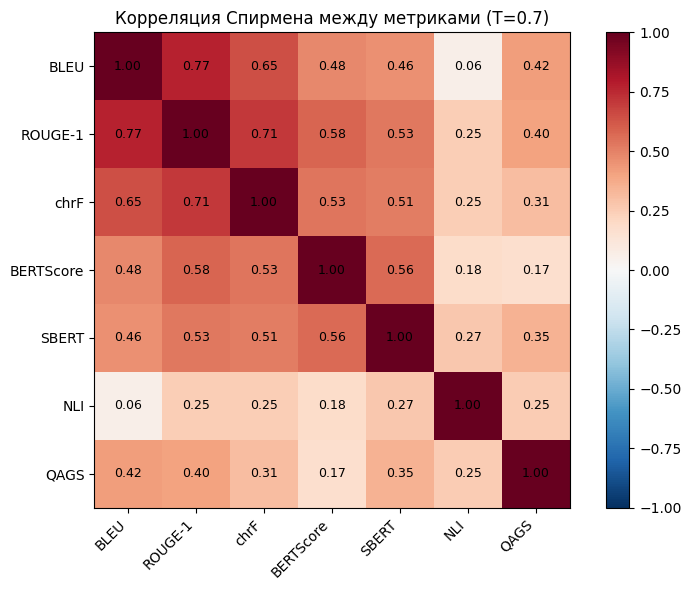

In [45]:
# корреляции
fig, ax = plt.subplots(figsize=(8, 6))
corr = scores_07.corr(method='spearman')
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)

for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9)

plt.colorbar(im)
plt.title("Корреляция Спирмена между метриками (T=0.7)")
plt.tight_layout()
plt.show()

### Выводы

1. **Нет универсальной метрики.** Каждая метрика измеряет свой аспект качества:
   - BLEU/ROUGE/chrF -> поверхностное совпадение с эталоном
   - BERTScore/SBERT -> семантическое сходство
   - NLI -> фактическая обоснованность контекстом
   - QAGS -> консистентность ответов
   - LLM-as-judge -> комплексная оценка (ближе к человеку)

2. **Начинайте с простого.** ROUGE/chrF как быстрый скрининг -> BERTScore для семантики -> NLI/LLM-judge для глубокой оценки.

3. **Для RAG обязательны контекстные метрики.** BLEU/ROUGE не покажут, галлюцинирует ли модель - нужны NLI, QAGS или RAGAS.

4. **LLM-as-judge - мощный, но опасный инструмент.** Всегда:
   - фиксируйте рубрику с примерами
   - рандомизируйте порядок
   - калибруйте на человеческой выборке
   - делайте несколько прогонов

5. **Воспроизводимость - основа.** Фиксируйте seed, версию модели, промпт, температуру. Без этого сравнение бессмысленно.

6. **Сделайте свой микробенчмарк** из 50–200 примеров, отражающих ваши кейсы, и гоняйте его в CI на каждой итерации промпта/модели/RAG.